## Description
This notebook implements a linear classifier on top of a pre-trained DINOv2 model using pytorch.
The model is trained using the cvn dataset and was saved in a pth file. We load the model and get the intermediate layers to extract features from the images.
The data loader was adapted to load images and their corresponding labels from the cvn dataset.

The dataset used here are located in /nfs/data/1/rrazakami/work/dune-cvn/dataset_info: few sampled images and simple folder structure. Once the classification is working, we can move to the full dataset at /nfs/data/1/rrazakami/work/data_cvn

In [1]:
import numpy as np
import os
from pathlib import Path
import time
import copy
import matplotlib.pyplot as plt
from PIL import Image
import shutil
from tqdm import tqdm

#### Data loader: copy from cvn.py

In [2]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.io import read_image
from torchvision.transforms import v2
from torchvision.models.feature_extraction import create_feature_extractor
from dinov2.models.vision_transformer import vit_small, vit_base, vit_large

XFORMERS_ENABLED= True


/nfs/data/1/rrazakami/work/dinov2ForLArTPC/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/nfs/data/1/rrazakami/work/dinov2ForLArTPC/dinov2/layers/attention.py:29: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/nfs/data/1/rrazakami/work/dinov2ForLArTPC/dinov2/layers/block.py:34: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [3]:
print(f'torch version: {torch.__version__}')
print(f'torchvision version: {torchvision.__version__}')

torch version: 2.3.1+cu121
torchvision version: 0.18.1+cu121


In [4]:
def fix_random_seeds(seed=53):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
fix_random_seeds()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')
print(f'Device count : {torch.cuda.device_count()}')

Using device: cuda
Device count : 2


### Preparing the file structure

In [6]:
DATA_SOURCE = '/nfs/data/1/rrazakami/work/dune-cvn/dataset_info'
DATA_ROOT = 'data_cvn'
os.makedirs(DATA_ROOT, exist_ok=True)
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [7]:
def create_dir_structure():
    def get_unique_filename(flavor='nutau'):
        # return unique list of prefixes in the flavor directory
        flavor_path = os.path.join(DATA_SOURCE, flavor)
        list_files = os.listdir(flavor_path)
        prefixes = [f.split('.')[0] for f in list_files if f.startswith('event')]
        unique_prefixes = list(set(prefixes))
        return unique_prefixes
    ## The particular dataset is balanced, so each flavor has the name number of events. This could be different for other datasets.
    N = len(get_unique_filename('nutau'))
    # N = 20
    print(f'Total number of events per flavor: {N}')

    # separate into train, val, test : 70%, 15%, 15%
    train_split = int(0.7 * N)
    val_split = int(0.15 * N)
    test_split = N - train_split - val_split
    # Each event is stored in a gz file with its corresponding .info file. We need to copy both files.
    ## Create train, val, and test directories
    train_path = os.path.join(DATA_ROOT, 'train')
    val_path = os.path.join(DATA_ROOT, 'val')
    test_path = os.path.join(DATA_ROOT, 'test')
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)
    # For each flavor, create subdirectories
    flavors = os.listdir(DATA_SOURCE)
    for flavor in flavors:
        os.makedirs(os.path.join(train_path, flavor), exist_ok=True)
        os.makedirs(os.path.join(val_path, flavor), exist_ok=True)
        os.makedirs(os.path.join(test_path, flavor), exist_ok=True)
    # Now, copy files into respective directories
    for flavor in flavors:
        list_files = get_unique_filename(flavor=flavor)
        flavor_path = os.path.join(DATA_SOURCE, flavor)
        for i, file in enumerate(list_files):
            src_file_gz = os.path.join(flavor_path, file + '.gz')
            src_file_info = os.path.join(flavor_path, file + '.info')
            if i < train_split:
                dest_dir = os.path.join(train_path, flavor)
            elif i < train_split + val_split:
                dest_dir = os.path.join(val_path, flavor)
            else:
                dest_dir = os.path.join(test_path, flavor)
            shutil.copy(src_file_gz, dest_dir)
            shutil.copy(src_file_info, dest_dir)

In [8]:
# create_dir_structure()

### Creating models for feature extraction

In [9]:
## class for DINOv2
class ModelWithIntermediateLayers(nn.Module):
    def __init__(self, feature_model, n_last_blocks):
        super().__init__()
        self.feature_model = feature_model
        self.feature_model.eval()
        self.n_last_blocks = n_last_blocks

    def forward(self, images):
        with torch.inference_mode():
            features = self.feature_model.get_intermediate_layers(images, self.n_last_blocks, return_class_token=True)
        return features

### Configuring the model

In [10]:
BACKBONE = 'dinov2'
model_configurator = {
    'dinov2': {
        'backbone_name': 'dinov2',
        'arch' : 'large',
        'use_nblocks' : 1,
        'use_avgpool': True,
    }
}
IMG_SIZE = 500 #168
BATCH_SIZE = 16 #8
NUM_WORKERS = 0
PATCH_SIZE = 25 #56

In [11]:
model_config = model_configurator[BACKBONE]
if BACKBONE=='dinov2':
    backbone_archs = {
        'small': vit_small,
        'base': vit_base,
        'large': vit_large
    }
    backbone_arch = backbone_archs[model_config['arch']]
    backbone_name = f'dinov2_{backbone_arch}'
    print(f'Using backbone: {backbone_name}')
    # load model
    backbone_model = vit_large(patch_size=PATCH_SIZE, img_size=IMG_SIZE)
    backbone_model.to(device)
    for p in backbone_model.parameters():
        p.requires_grad = False
    backbone_model.eval()
    pth_model = torch.load('../out_cvn_memlite_batchpergpu_16/model_final.rank_0.pth')
    backbone_model.load_state_dict(pth_model, strict=False)
    feature_model = ModelWithIntermediateLayers(backbone_model, n_last_blocks=model_config['use_nblocks'])
    embed_dim = backbone_model.embed_dim * (model_config['use_nblocks'] + int(model_config['use_avgpool']))

feature_model = feature_model.to(device)

Using backbone: dinov2_<function vit_large at 0x7f62d8f34b80>


### Creating a linear classifier

In [12]:
def create_linear_input(x_tokens_list, use_nblocks, use_avgpool):
    intermediate_output = x_tokens_list[-use_nblocks:]  # list of tensors from the last n blocks
    output = torch.cat([class_token for _, class_token in intermediate_output], dim=-1)  # concatenate class tokens
    if use_avgpool:
        output = torch.cat(
            (
                output,
                torch.mean(intermediate_output[-1][0], dim=1), # patch tokens
            ),
            dim=-1,
        )
        output = output.reshape(output.shape[0], -1)
    return output.float()

In [13]:
class LinearClassifier(nn.Module):
    def __init__(self, out_dim, config, num_classes=4):
        super().__init__()
        self.out_dim = out_dim
        if config['backbone_name'] == 'dinov2':
            self.use_dinov2= True
            self.use_nblocks = config['use_nblocks']
            self.use_avgpool = config['use_avgpool']
        self.num_classes = num_classes
        self.linear = nn.Linear(self.out_dim, self.num_classes)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()
    
    def forward(self, input):
        if self.use_dinov2:
            output = create_linear_input(input, self.use_nblocks, self.use_avgpool)
            return self.linear(output)

linear_classifier = LinearClassifier(embed_dim, model_config, num_classes=6) # nu and nubar
linear_classifier = linear_classifier.to(device)

In [14]:
linear_classifier

LinearClassifier(
  (linear): Linear(in_features=2048, out_features=6, bias=True)
)

### Defining datasets and dataloaders

In [15]:
from dinov2.data import DataAugmentationDINO, SamplerType, make_data_loader, make_dataset
from dinov2.data import MaskingGenerator, collate_data_and_cast
from functools import partial
import yaml

with open('../dinov2/configs/ssl_default_config.yaml') as f:
    cfg = yaml.safe_load(f)
# cfg = yaml.safe_load(open('../dinov2/configs/ssl_default_config.yaml'))
cfg['train']['batch_size_per_gpu'] = BATCH_SIZE
cfg['crops']['global_crops_size'] = IMG_SIZE
cfg['student']['patch_size'] = PATCH_SIZE

img_size = cfg["crops"]["global_crops_size"]
patch_size = cfg["student"]["patch_size"]

In [16]:
n_tokens = (img_size // patch_size) ** 2  # +1 for CLS token
mask_generator = MaskingGenerator(
        input_size=(img_size // patch_size, img_size // patch_size),
        max_num_patches=0.5 * img_size // patch_size * img_size // patch_size,
    )

data_transform = DataAugmentationDINO(
    global_crops_scale=cfg["crops"]["global_crops_scale"],
    global_crops_size=cfg["crops"]["global_crops_size"],
    local_crops_size=cfg["crops"]["local_crops_size"],
)

collate_fn = partial(
    collate_data_and_cast,
    mask_ratio_tupe=cfg["ibot"]["mask_ratio_min_max"],
    mask_probability=cfg["ibot"]["mask_sample_probability"],
    n_tokens=n_tokens,
    mask_generator=mask_generator,
    dtype=torch.half,
)

kwargs = {}
datasets = {x: make_dataset(dataset_str=f"CVN:root={DATA_ROOT}/{x}", transform=data_transform,
                            target_transform=None) for x in ['train', 'val']}
dataloaders = {x: make_data_loader(
    dataset=datasets[x],
    batch_size=cfg["train"]["batch_size_per_gpu"],
    num_workers=cfg["train"]["num_workers"],
    shuffle=True,
    sampler_type=SamplerType.EPOCH
) for x in ['train', 'val']}

dataset_sizes = {x: len(datasets[x]) for x in ['train', 'val']}
# class_names = datasets['train'].classes()
class_names = datasets['train'].pdgs

print(f"Data loaded with {dataset_sizes['train']} training samples and {dataset_sizes['val']} validation samples.")

Data loaded with 420 training samples and 90 validation samples.


In [17]:
class_names

[12, 14, 16, -12, -14, -16]

In [18]:
datasets['test'] = make_dataset(dataset_str=f"CVN:root={DATA_ROOT}/test", transform=data_transform,
                            target_transform=None)
dataloaders['test'] = make_data_loader(
    dataset=datasets['test'],
    batch_size=cfg["train"]["batch_size_per_gpu"],
    num_workers=cfg["train"]["num_workers"],
    shuffle=True,
)
dataset_sizes['test'] = len(datasets['test'])
print(f'Data loaded with {dataset_sizes["test"]} test samples.')

Data loaded with 90 test samples.


### Visualizing some examples

In [19]:
def show_batch(imgs, titles=None, rows=2, cols=4):
    if titles is None:
        titles = ['image ' + str(i) for i in range(imgs.size(0))]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    fig = plt.figure(figsize=(cols * 3, rows * 3))
    for i in range(imgs.size(0)):
        print(f'imgs.size() : {imgs.size()}')
        print(f'imgs.size(0) : {imgs.size(0)}')
        img = imgs[i].cpu().numpy().transpose((1, 2, 0))
        print(f'image shape : {img.shape}')
        # img = img * std + mean  # unnormalize
        img = np.clip(img, 0, 1)
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(img)
        ax.set_title(titles[i])
        ax.axis('off')
    fig.tight_layout()

imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size(

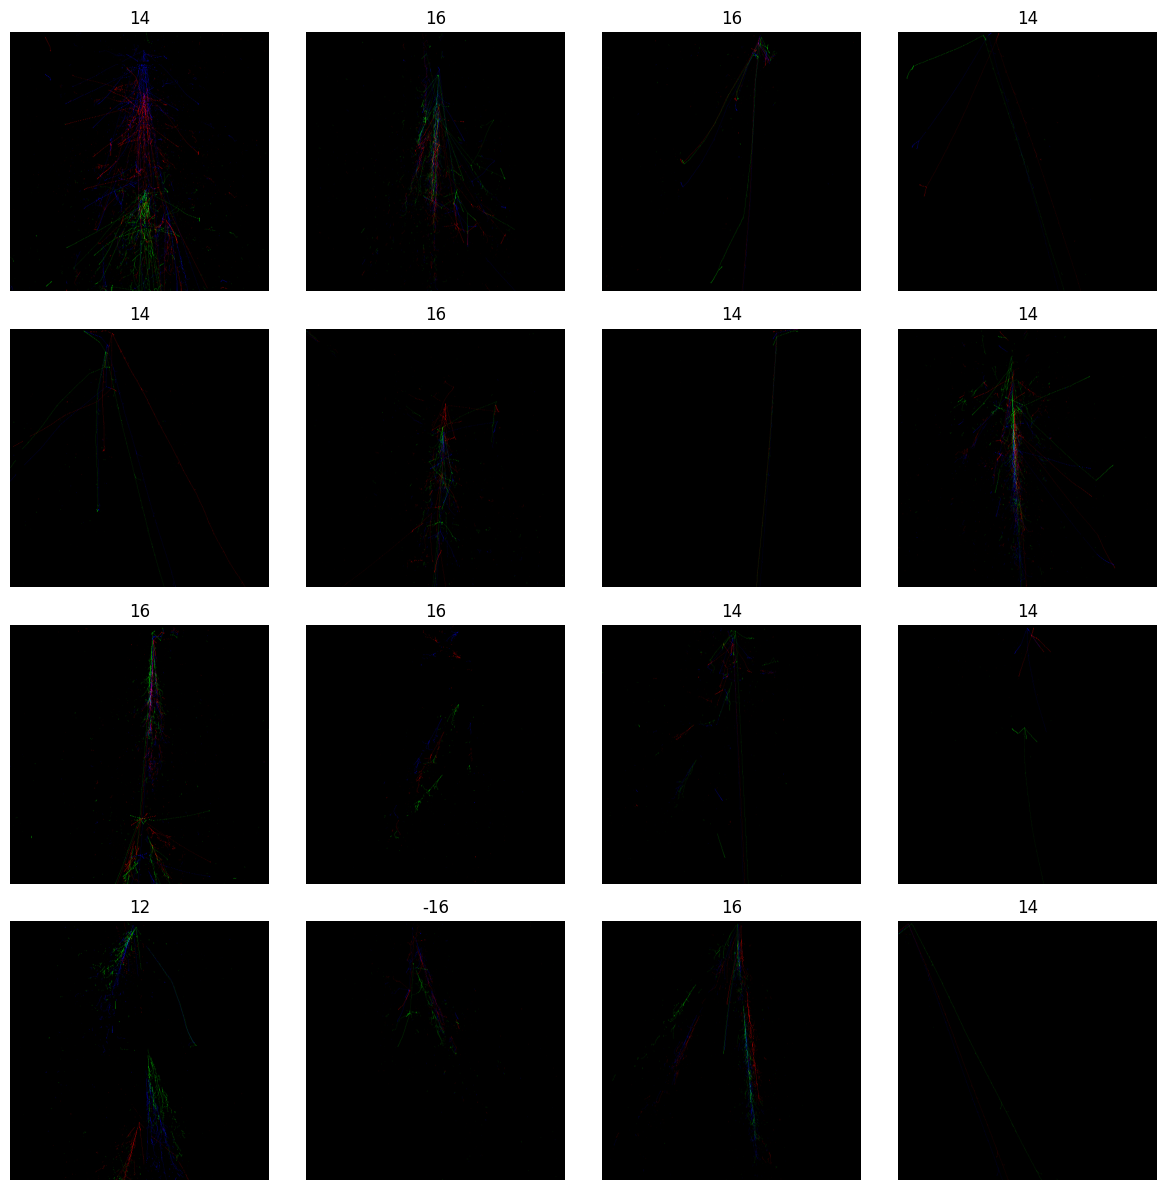

In [20]:
inputs, classes = next(iter(dataloaders['train']))

nu_PDGs = {
    12: r'$\nu_e$',
    -12: r'$\bar{\nu}_e$',
    14: r'$\nu_{\mu}$',
    -14: r'$\bar{\nu}_{\mu}$',
    16: r'$\nu_{\tau}$',
    -16: r'$\bar{\nu}_{\tau}$',
}
show_batch(inputs, titles=[class_names[cls] for cls in classes], rows=4, cols=4)
# show_batch(inputs, titles=[f'{nu_PDGs[cls.item()]}, PDG = {cls.item()}' for cls in classes], rows=4, cols=4)

imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size(

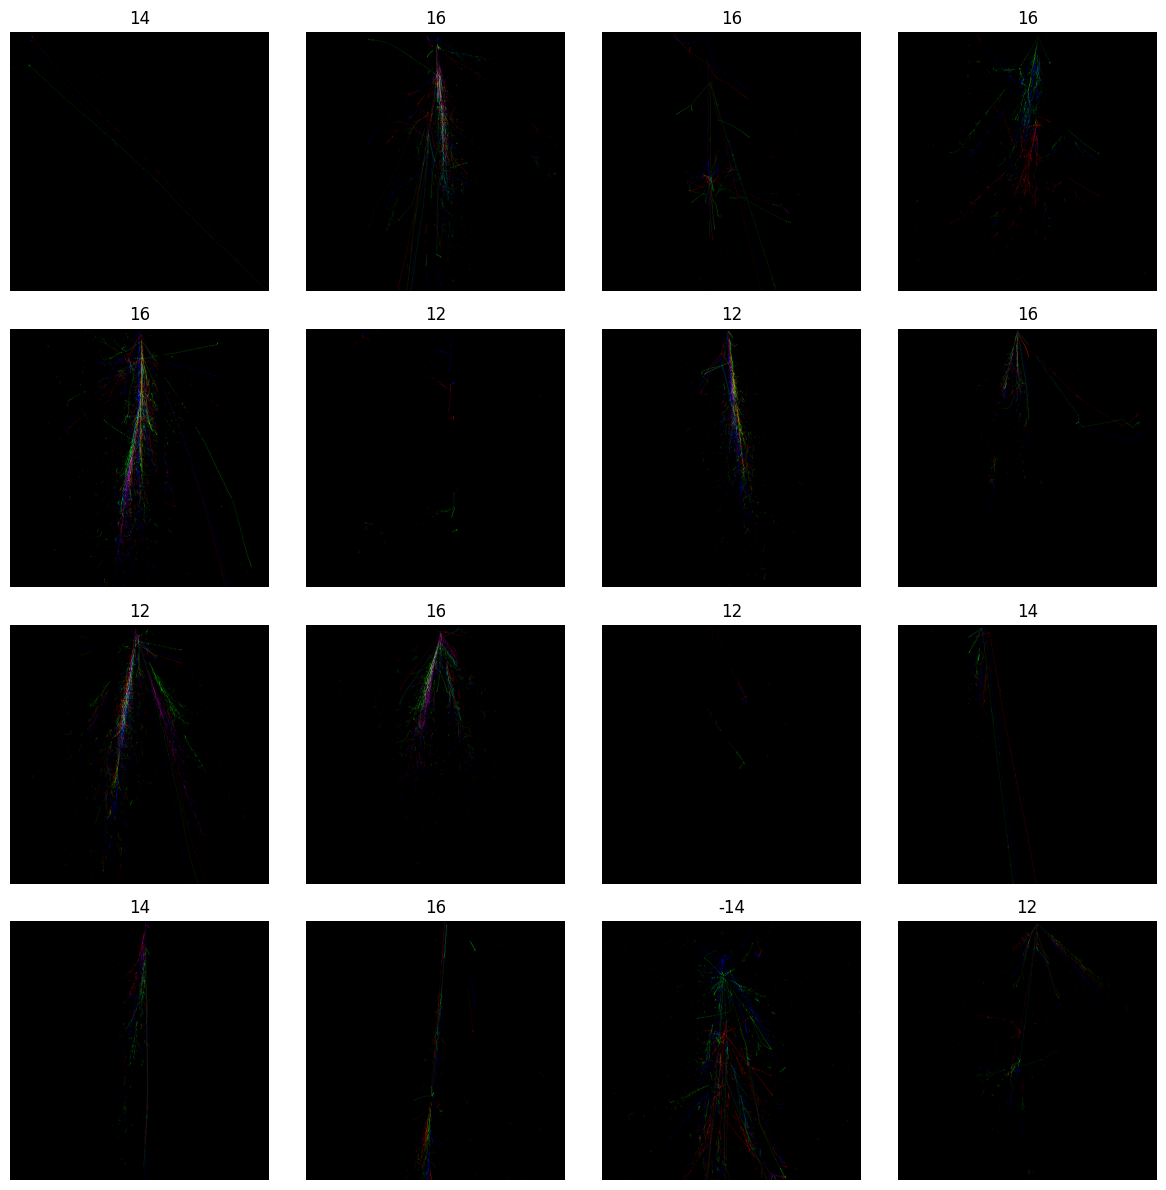

In [21]:
inputs, classes = next(iter(dataloaders['val']))
show_batch(inputs, titles=[class_names[cls] for cls in classes], rows=4, cols=4)
# show_batch(inputs, titles=[f'{nu_PDGs[cls.item()]}, PDG = {cls.item()}' for cls in classes], rows=4, cols=4)

imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size(

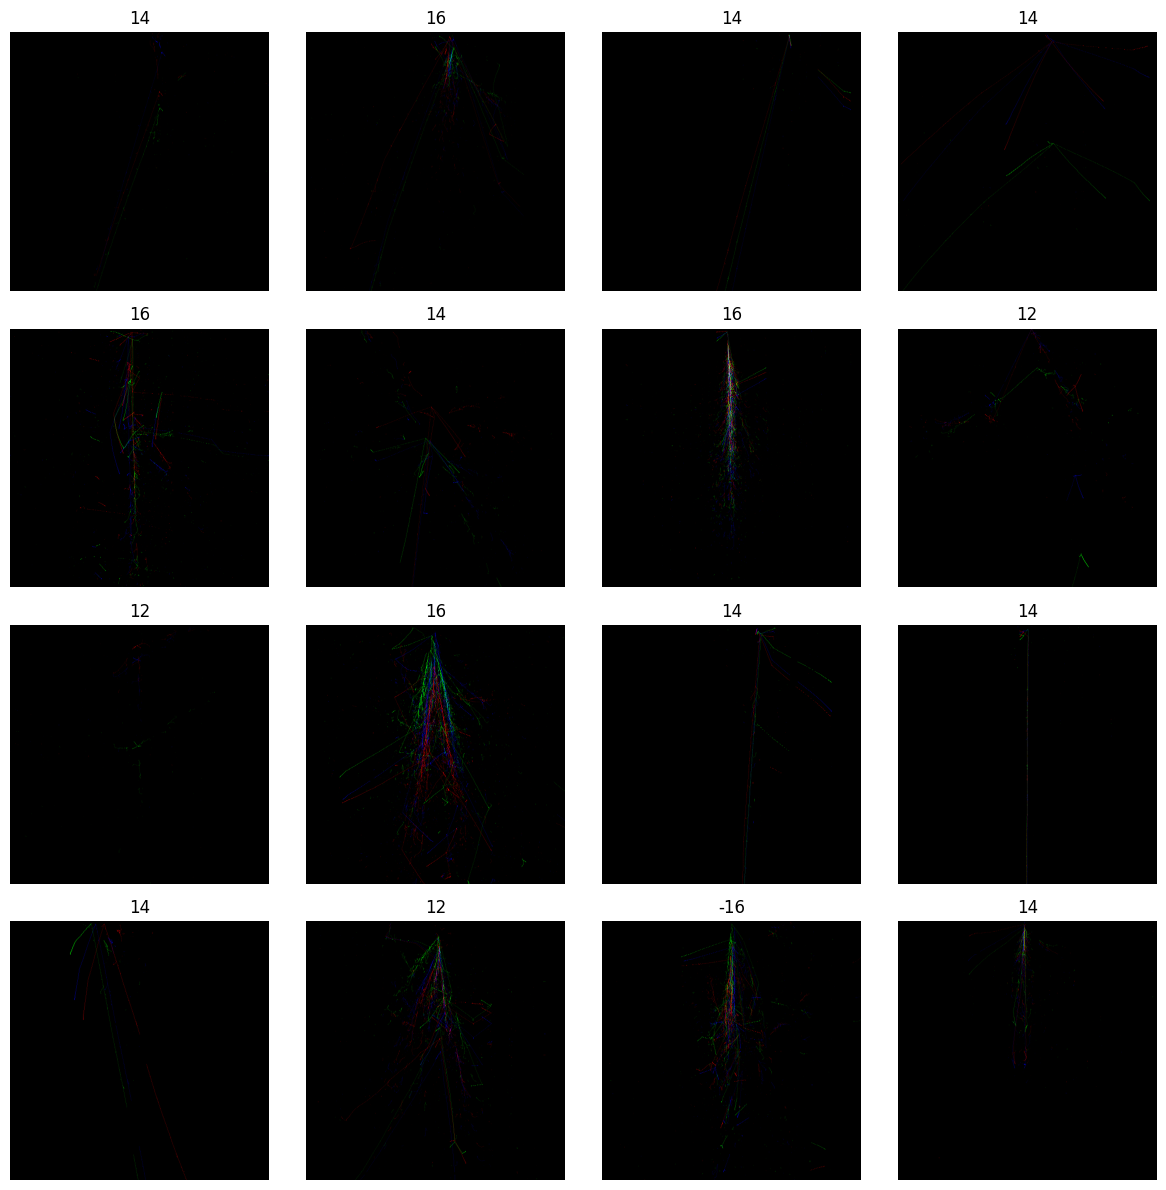

In [22]:
inputs, classes = next(iter(dataloaders['test']))
show_batch(inputs, titles=[class_names[cls] for cls in classes], rows=4, cols=4)
# show_batch(inputs, titles=[f'{nu_PDGs[cls.item()]}, PDG = {cls.item()}' for cls in classes], rows=4, cols=4)

### Train and validation loops

In [23]:
def train_loop(dataloader, feature_model, linear_classifier, loss_fn, optimizer):
    linear_classifier.train()
    size = len(dataloader.dataset)
    print(f'Dataset size: {size}')
    total_samples = 0
    # num_batches = len(dataloader[0]['global_crops'])
    num_batches = BATCH_SIZE
    running_loss = 0.0
    running_corrects = 0
    for batch, (X,y) in enumerate(dataloader):
        print(f'Batch {batch+1}/{num_batches}', end='\r')
        X = X.to(device)
        y = y.to(device)
        features = feature_model(X)
        # f = features[0][0].cpu().numpy()
        # features = feature_model.forward(X)
        pred = linear_classifier(features)
        # print(f'pred shape : {pred.shape}, values : {pred}')
        # print(f'y shape : {y.shape}, values : {y}')
        loss = loss_fn(pred, y)
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        # Statistics
        running_loss += loss.item()
        running_corrects += (pred.argmax(1) == y).type(torch.float).sum().item()
        total_samples += y.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    print(f'len(running_corrects) : {running_corrects}, total_samples : {total_samples}')
    return epoch_acc, epoch_loss

In [24]:
@torch.inference_mode()
def val_loop(dataloader, feature_model, linear_classifier, loss_fn):
    linear_classifier.eval()
    size = len(dataloader.dataset)
    total_samples = 0
    num_batches = BATCH_SIZE
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            features = feature_model(X)
            # features = feature_model.forward_backward(X)
            pred = linear_classifier(features)
            val_loss += loss_fn(pred, y).item()
            val_acc += (pred.argmax(1) == y).type(torch.float).sum().item()
            total_samples += y.size(0)
    val_loss /= total_samples
    val_acc /= total_samples
    return val_acc, val_loss

### Loss function, optimizer, scheduler

In [25]:
EPOCHS = 100
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    linear_classifier.parameters(),
    # lr=cfg['optim']['base_lr'],
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS, eta_min=0)

In [26]:
best_acc = 0.0
best_acc_loss = np.inf
train_data = []
for t in range(EPOCHS): # epochs
    print(f'Epoch {t+1}\n-------------------------------')

    train_acc, train_loss = train_loop(dataloaders['train'], feature_model, linear_classifier, loss_fn, optimizer)
    train_data.append({
        'phase': 'train',
        'epoch': t,
        'lr': optimizer.param_groups[0]['lr'],
        'accuracy': train_acc,
        'loss': train_loss
    })
    scheduler.step()
    print(f'Train: \n  Train_acc = {train_acc:.4f}, Train_loss = {train_loss:.4f}')
    val_acc, val_loss = val_loop(dataloaders['val'], feature_model, linear_classifier, loss_fn)
    print(f'Validation:\n    val_acc = {val_acc}, val_loss = {val_loss}')
    train_data.append({
        'phase': 'val',
        'epoch': t,
        'lr': optimizer.param_groups[0]['lr'],
        'accuracy': val_acc,
        'loss': val_loss
    })
    if (val_acc == best_acc and val_loss < best_acc_loss) or (val_acc > best_acc):
        best_acc, best_acc_loss = val_acc, val_loss
        save_dict = {
            'epoch': t+1,
            'state_dict': linear_classifier.state_dict(),
            'optimizer': optimizer.state_dict(),
            'best_acc': best_acc,
            'best_acc_loss': best_acc_loss
        }
        torch.save(save_dict, os.path.join(OUTPUT_DIR, 'linear_classifier_best.pth'))
    print('\n')
print('Training completed.')

Epoch 1
-------------------------------
Dataset size: 420


len(running_corrects) : 124.0, total_samples : 416
Train: 
  Train_acc = 0.2981, Train_loss = 0.1029
Validation:
    val_acc = 0.275, val_loss = 0.0937704473733902


Epoch 2
-------------------------------
Dataset size: 420
len(running_corrects) : 136.0, total_samples : 416
Train: 
  Train_acc = 0.3269, Train_loss = 0.0986
Validation:
    val_acc = 0.275, val_loss = 0.08813754320144654


Epoch 3
-------------------------------
Dataset size: 420
len(running_corrects) : 143.0, total_samples : 416
Train: 
  Train_acc = 0.3438, Train_loss = 0.0954
Validation:
    val_acc = 0.275, val_loss = 0.08766304701566696


Epoch 4
-------------------------------
Dataset size: 420
len(running_corrects) : 141.0, total_samples : 416
Train: 
  Train_acc = 0.3389, Train_loss = 0.0944
Validation:
    val_acc = 0.275, val_loss = 0.08645809143781662


Epoch 5
-------------------------------
Dataset size: 420
len(running_corrects) : 144.0, total_samples : 416
Train: 
  Train_acc = 0.3462, Train_loss = 0.0936


### Model information

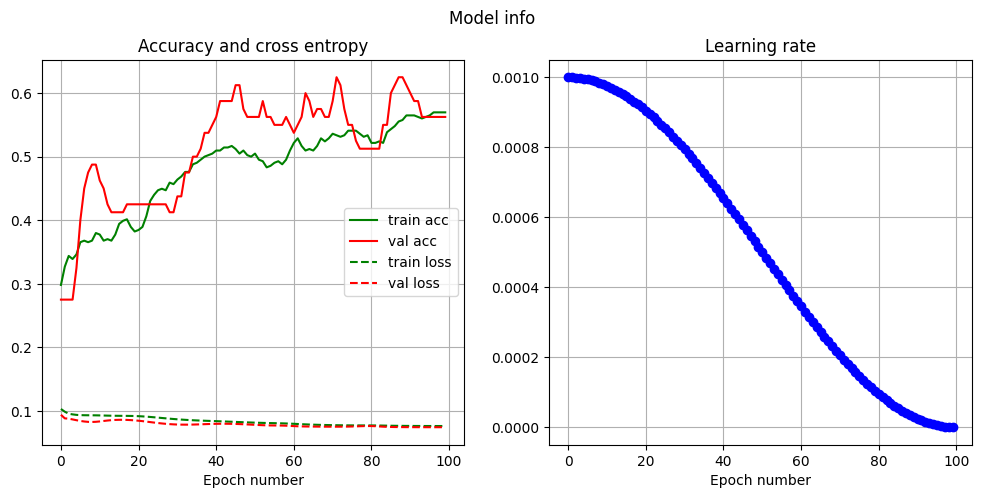

In [27]:
import pandas as pd
train_df = pd.DataFrame(train_data)
train_df.to_csv(os.path.join(OUTPUT_DIR, 'training_log.csv'), index=False)
train_phase = train_df[train_df['phase']=='train']
val_phase = train_df[train_df['phase']=='val']
y_axis = 'accuracy'
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))
line_acc_train, = ax1.plot(train_phase['epoch'], train_phase['accuracy'], 'g-', label='train acc')
line_acc_val, = ax1.plot(val_phase['epoch'], val_phase['accuracy'], 'r-', label='val acc')
line_loss_train, = ax1.plot(train_phase['epoch'], train_phase['loss'], 'g--', label='train loss')
line_loss_val, = ax1.plot(val_phase['epoch'], val_phase['loss'], 'r--', label='val loss')
ax1.set_xlabel('Epoch number')
ax1.legend(loc='center right')
ax1.set_title('Accuracy and cross entropy')
ax1.grid(visible=True)
line_lr = ax2.plot(train_phase['epoch'], train_phase['lr'], 'ob', label='learning rate')
ax2.set_xlabel('Epoch number')
ax2.set_title('Learning rate')
ax2.grid(visible=True)
fig.suptitle('Model info')
plt.show()

### Visualization of predictions

In [28]:
def visualize_model(feature_model, linear_classifier, images, rows=2, cols=4, true_classes=None):
    was_training = linear_classifier.training
    linear_classifier.eval()

    with torch.no_grad():
        imgs = images.to(device)
        print(f'Input image shape: {imgs.shape}')
        features = feature_model(imgs)
        outputs = linear_classifier(features)
        outputs = nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        titles = [f'{class_names[preds[i]]}: {outputs[i, preds[i]].squeeze().item():.3f}; true : {class_names[true_classes[i]]}' for i in range(imgs.size(0))]
    show_batch(imgs, titles=titles, rows=rows, cols=cols)
    
    linear_classifier.train(mode=was_training)

Input image shape: torch.Size([16, 3, 500, 500])
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.size(0) : 16
image shape : (500, 500, 3)
imgs.size() : torch.Size([16, 3, 500, 500])
imgs.si

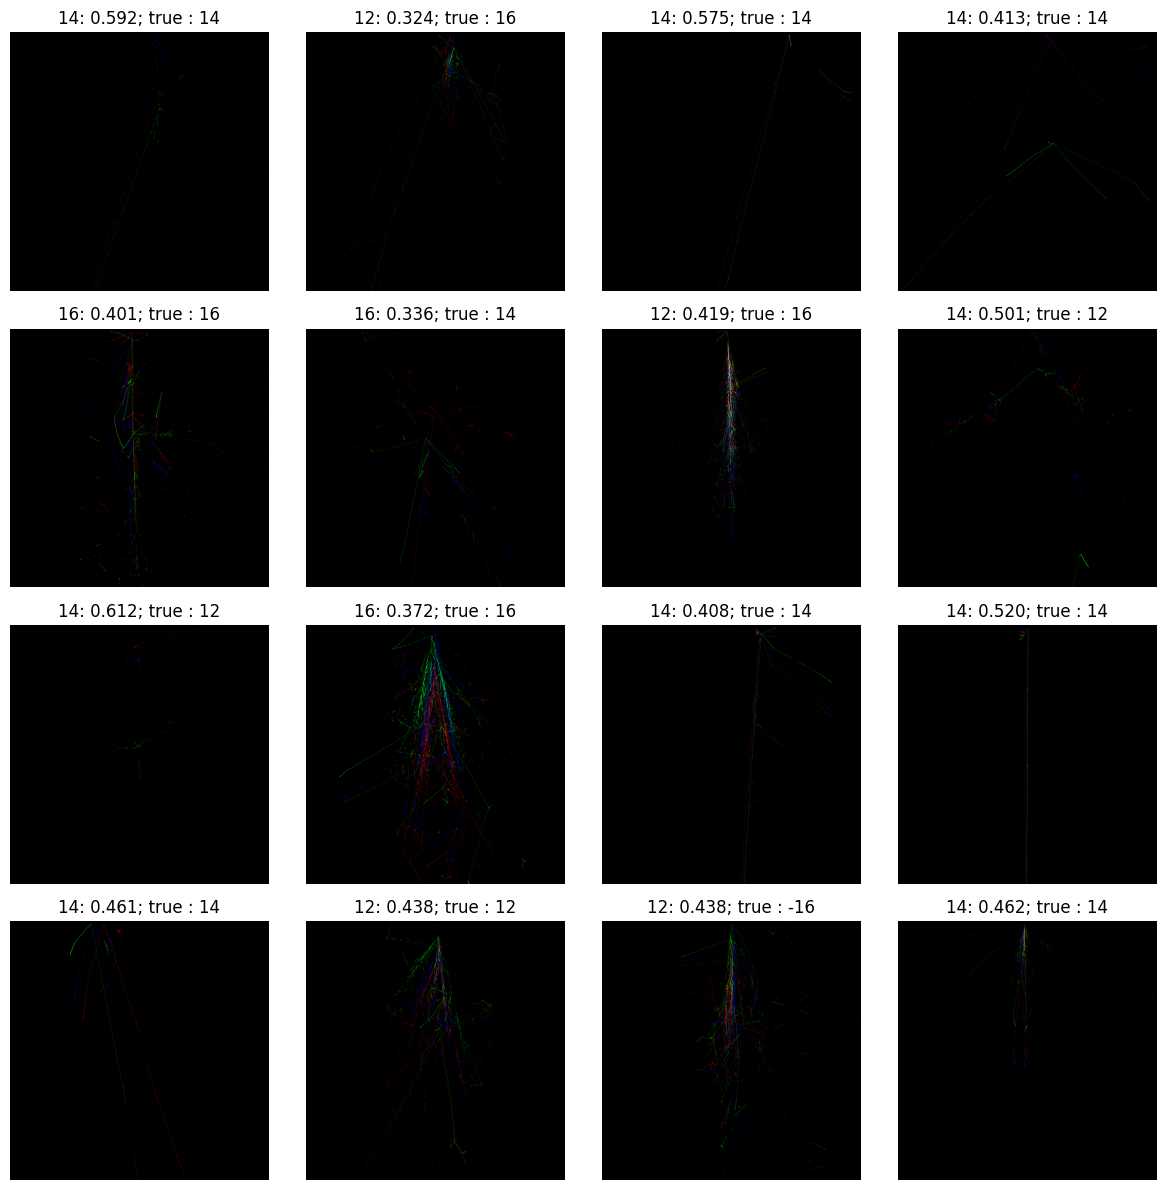

In [29]:
imgs, true_classes = next(iter(dataloaders['test']))
visualize_model(feature_model=feature_model, linear_classifier=linear_classifier, images=imgs, true_classes=true_classes, rows=4, cols=4)